# 03 – Convolutional Neural Network (CNN)

Este notebook implementa e avalia modelos CNN para classificação de borboletas (75 classes).

## Experiências realizadas
| Experimento | Arquitectura | Loss | Optimizador |
|-------------|-------------|------|-------------|
| CNN-A_CrossEntropy_RMSprop | Pequena (3 blocos) | CrossEntropy | RMSprop |
| CNN-A_CrossEntropy_Adam    | Pequena (3 blocos) | CrossEntropy | Adam    |
| CNN-A_MultiMargin_RMSprop  | Pequena (3 blocos) | MultiMargin  | RMSprop |
| CNN-A_MultiMargin_Adam     | Pequena (3 blocos) | MultiMargin  | Adam    |
| CNN-B_CrossEntropy_RMSprop | Grande (5 blocos)  | CrossEntropy | RMSprop |
| CNN-B_CrossEntropy_Adam    | Grande (5 blocos)  | CrossEntropy | Adam    |
| CNN-B_MultiMargin_RMSprop  | Grande (5 blocos)  | MultiMargin  | RMSprop |
| CNN-B_MultiMargin_Adam     | Grande (5 blocos)  | MultiMargin  | Adam    |

## 1. Importações e configuração

In [6]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
import json
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, top_k_accuracy_score
)
import kagglehub

# Reproducibilidade
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


## 2. Pipeline de dados

Mantemos o mesmo split 80/20 estratificado e a mesma semente do notebook MLP,
para que a comparação de desempenho seja justa.

### Métricas usadas
- **Accuracy**: métrica primária – dataset ligeiramente desbalanceado (57–105 imgs/classe).
- **Macro F1-Score**: penaliza erros em classes pequenas (complemento à accuracy).
- **Top-5 Accuracy**: útil em 75 classes visualmente semelhantes.
- **Confusion matrix**: inspecção qualitativa de padrões de confusão.

### Data augmentation
As CNNs beneficiam de augmentation mais agressivo do que os MLPs, pois os filtros
são partilhados espacialmente e precisam de aprender invariâncias a rotação/espelho.

In [7]:
# ── Hiperparâmetros globais ─────────────────────────────────────────────────
BATCH_SIZE  = 64
IMAGE_SIZE  = 96        # CNN beneficia de imagens maiores que o MLP (64→96)
NUM_CLASSES = 75
NUM_EPOCHS  = 30
LR          = 1e-3
VAL_SPLIT   = 0.2       # 20 % de validação (igual ao MLP)

# ── Download do dataset ──────────────────────────────────────────────────────
path = kagglehub.competition_download('aca-butterflies')
img_dir   = os.path.join(path, 'train')
train_csv = os.path.join(path, 'train.csv')
print(f'Dataset em: {path}')

df = pd.read_csv(train_csv)
print(f'Total de amostras: {len(df)}  |  Classes: {df["label"].nunique()}')

Dataset em: /Users/matildecarvalho/.cache/kagglehub/competitions/aca-butterflies
Total de amostras: 5199  |  Classes: 75


In [8]:
# ── Mapeamento classe → índice ───────────────────────────────────────────────
classes = sorted(df['label'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
print(f'Número de classes: {len(classes)}')

Número de classes: 75


In [9]:
class ButterflyDataset(data.Dataset):
    """Dataset de borboletas para o projeto ACA."""

    def __init__(self, df, img_dir, class_to_idx, transform=None):
        self.img_labels   = df.reset_index(drop=True)
        self.img_dir      = img_dir
        self.class_to_idx = class_to_idx
        self.transform    = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        row      = self.img_labels.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')
        label    = torch.tensor(self.class_to_idx[row['label']], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        return image, label

In [10]:
# ── Transforms ──────────────────────────────────────────────────────────────
# Augmentation mais rico para CNN: espelho, recorte aleatório, colorjitter
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 16, IMAGE_SIZE + 16)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Train / Validation split ─────────────────────────────────────────────────
df_train, df_val = train_test_split(
    df, test_size=VAL_SPLIT, random_state=SEED,
    stratify=df['label']   # mantém proporção de classes
)
print(f'Treino: {len(df_train)}  | Validação: {len(df_val)}')

train_ds = ButterflyDataset(df_train, img_dir, class_to_idx, train_transform)
val_ds   = ButterflyDataset(df_val,   img_dir, class_to_idx, val_transform)

train_loader = data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = data.DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Batches treino: {len(train_loader)}  |  Batches val: {len(val_loader)}')

Treino: 4159  | Validação: 1040
Batches treino: 65  |  Batches val: 17


## 3. Arquiteturas CNN

### Bloco convolucional
Cada bloco segue o padrão:  
`Conv2d → BatchNorm2d → ReLU → (opcional MaxPool2d)`

### CNN-A – Pequena (3 blocos)
```
Conv(3→32)  BN ReLU MaxPool(2)   → 32 × 48 × 48
Conv(32→64) BN ReLU MaxPool(2)   → 64 × 24 × 24
Conv(64→128) BN ReLU MaxPool(2)  → 128 × 12 × 12 (com IMAGE_SIZE=96)
Flatten → FC(128·12·12 → 512) BN ReLU Dropout(0.5) → FC(512 → 75)
```
~8.5 M parâmetros.

### CNN-B – Grande (5 blocos + AdaptiveAvgPool)
```
Conv(3→32)   BN ReLU
Conv(32→32)  BN ReLU MaxPool(2)   → 32 × 48 × 48
Conv(32→64)  BN ReLU
Conv(64→64)  BN ReLU MaxPool(2)   → 64 × 24 × 24
Conv(64→128) BN ReLU
Conv(128→128) BN ReLU MaxPool(2)  → 128 × 12 × 12
AdaptiveAvgPool(4×4)              → 128 × 4 × 4
Flatten → FC(128·4·4 → 256) Dropout(0.5) → FC(256 → 75)
```
~2.7 M parâmetros (menos que o MLP!), mais profundo e com melhor regularização.

In [11]:
def conv_block(in_ch, out_ch, pool=True):
    """Bloco Conv → BN → ReLU → (MaxPool)."""
    layers = [
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    ]
    if pool:
        layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)


class CNN_A(nn.Module):
    """CNN pequena: 3 blocos convolucionais."""
    def __init__(self, num_classes=75, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            conv_block( 3,  32, pool=True),   # 96→48
            conv_block(32,  64, pool=True),   # 48→24
            conv_block(64, 128, pool=True),   # 24→12
        )
        # Após 3 × MaxPool(2) em 96×96: 12×12
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class CNN_B(nn.Module):
    """CNN grande: 6 blocos conv + AdaptiveAvgPool."""
    def __init__(self, num_classes=75, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            conv_block( 3,  32, pool=False),  # 96×96
            conv_block(32,  32, pool=True),   # 96→48
            conv_block(32,  64, pool=False),  # 48×48
            conv_block(64,  64, pool=True),   # 48→24
            conv_block(64, 128, pool=False),  # 24×24
            conv_block(128,128, pool=True),   # 24→12
        )
        self.pool = nn.AdaptiveAvgPool2d(4)   # → 128×4×4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


# ── Sanity check ─────────────────────────────────────────────────────────────
dummy = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE)
for name, cls in [('CNN-A', CNN_A), ('CNN-B', CNN_B)]:
    m = cls(NUM_CLASSES)
    out = m(dummy)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name}: output={tuple(out.shape)}  parâmetros={params:,}')

CNN-A: output=(4, 75)  parâmetros=9,570,667
CNN-B: output=(4, 75)  parâmetros=831,275


## 4. Função de treino e avaliação

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    acc  = correct / total
    loss = total_loss / total
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    top5 = top_k_accuracy_score(all_labels, np.array(all_probs), k=5)
    return loss, acc, f1, top5, all_preds, all_labels


def train_model(model_cls, arch_name, loss_name, opt_name,
                num_epochs=NUM_EPOCHS, lr=LR, device=DEVICE):
    """
    Treina uma CNN com a arquitectura, loss e optimizador especificados.
    Devolve o histórico e o modelo com melhor val-accuracy.
    """
    exp_name = f'CNN-{arch_name}_{loss_name}_{opt_name}'
    print(f'\n{"="*60}')
    print(f' Experimento: {exp_name}')
    print(f'{"="*60}')

    # Modelo
    model = model_cls(NUM_CLASSES).to(device)

    # Loss
    if loss_name == 'CrossEntropy':
        criterion = nn.CrossEntropyLoss()
    elif loss_name == 'MultiMargin':
        criterion = nn.MultiMarginLoss()
    else:
        raise ValueError(f'Loss desconhecida: {loss_name}')

    # Optimizador
    if opt_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f'Optimizador desconhecido: {opt_name}')

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4
    )

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   [],
               'val_f1':     [], 'val_top5':  []}

    best_acc, best_state = 0.0, None
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, vl_f1, vl_top5, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl_acc)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_f1'].append(vl_f1)
        history['val_top5'].append(vl_top5)

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{num_epochs} | '
                  f'TrLoss={tr_loss:.4f} TrAcc={tr_acc:.3f} | '
                  f'VlLoss={vl_loss:.4f} VlAcc={vl_acc:.3f} F1={vl_f1:.3f} Top5={vl_top5:.3f}')

    elapsed = time.time() - t0
    print(f'  Tempo total: {elapsed:.1f}s  |  Melhor val_acc: {best_acc:.4f}')

    model.load_state_dict(best_state)
    return model, history, best_acc

## 5. Execução de todos os experimentos

Executamos 8 combinações (2 arquitecturas × 2 losses × 2 optimizadores).

> **Nota:** cada execução treina durante `NUM_EPOCHS` epochs com `ReduceLROnPlateau`.

In [13]:
EXPERIMENTS = [
    (CNN_A, 'A', 'CrossEntropy', 'RMSprop'),
    (CNN_A, 'A', 'CrossEntropy', 'Adam'),
    (CNN_A, 'A', 'MultiMargin',  'RMSprop'),
    (CNN_A, 'A', 'MultiMargin',  'Adam'),
    (CNN_B, 'B', 'CrossEntropy', 'RMSprop'),
    (CNN_B, 'B', 'CrossEntropy', 'Adam'),
    (CNN_B, 'B', 'MultiMargin',  'RMSprop'),
    (CNN_B, 'B', 'MultiMargin',  'Adam'),
]

models   = {}   # {exp_name: model}
histories = {}  # {exp_name: history}
results  = {}   # {exp_name: {val_acc, val_f1, val_top5}}

for model_cls, arch, loss_name, opt_name in EXPERIMENTS:
    exp_name = f'CNN-{arch}_{loss_name}_{opt_name}'
    model, hist, best_acc = train_model(model_cls, arch, loss_name, opt_name)

    # Avaliação final com o melhor modelo
    criterion = nn.CrossEntropyLoss() if loss_name == 'CrossEntropy' else nn.MultiMarginLoss()
    _, vl_acc, vl_f1, vl_top5, preds, labels_gt = evaluate(model, val_loader, criterion, DEVICE)

    models[exp_name]    = model
    histories[exp_name] = hist
    results[exp_name]   = {
        'val_acc':  vl_acc,
        'val_f1':   vl_f1,
        'val_top5': vl_top5,
        'preds':    preds,
        'labels':   labels_gt,
    }

print('\n✓ Todos os experimentos concluídos.')


 Experimento: CNN-A_CrossEntropy_RMSprop
  Epoch   1/30 | TrLoss=3.4132 TrAcc=0.169 | VlLoss=2.9986 VlAcc=0.221 F1=0.204 Top5=0.548
  Epoch   5/30 | TrLoss=1.5386 TrAcc=0.574 | VlLoss=1.4050 VlAcc=0.607 F1=0.597 Top5=0.875
  Epoch  10/30 | TrLoss=1.0335 TrAcc=0.702 | VlLoss=1.4819 VlAcc=0.581 F1=0.577 Top5=0.854
  Epoch  15/30 | TrLoss=0.7565 TrAcc=0.779 | VlLoss=1.2369 VlAcc=0.650 F1=0.644 Top5=0.896
  Epoch  20/30 | TrLoss=0.5839 TrAcc=0.828 | VlLoss=0.9499 VlAcc=0.719 F1=0.718 Top5=0.930
  Epoch  25/30 | TrLoss=0.4694 TrAcc=0.857 | VlLoss=1.1953 VlAcc=0.662 F1=0.663 Top5=0.909
  Epoch  30/30 | TrLoss=0.3810 TrAcc=0.881 | VlLoss=0.8639 VlAcc=0.768 F1=0.768 Top5=0.938
  Tempo total: 380.9s  |  Melhor val_acc: 0.7683

 Experimento: CNN-A_CrossEntropy_Adam
  Epoch   1/30 | TrLoss=3.3532 TrAcc=0.181 | VlLoss=2.5835 VlAcc=0.355 F1=0.323 Top5=0.687
  Epoch   5/30 | TrLoss=1.4841 TrAcc=0.600 | VlLoss=1.4792 VlAcc=0.596 F1=0.591 Top5=0.852
  Epoch  10/30 | TrLoss=0.9244 TrAcc=0.739 | VlLoss

/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/nn/functional.py:4231: UserWarning: The operator 'aten::multi_margin_loss' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  return torch._C._nn.multi_margin_loss(


  Epoch   1/30 | TrLoss=0.4428 TrAcc=0.136 | VlLoss=0.1900 VlAcc=0.299 F1=0.275 Top5=0.658
  Epoch   5/30 | TrLoss=0.1002 TrAcc=0.435 | VlLoss=0.0818 VlAcc=0.506 F1=0.494 Top5=0.838
  Epoch  10/30 | TrLoss=0.0586 TrAcc=0.556 | VlLoss=0.0627 VlAcc=0.584 F1=0.575 Top5=0.885
  Epoch  15/30 | TrLoss=0.0379 TrAcc=0.626 | VlLoss=0.0471 VlAcc=0.616 F1=0.614 Top5=0.911
  Epoch  20/30 | TrLoss=0.0291 TrAcc=0.689 | VlLoss=0.0439 VlAcc=0.658 F1=0.652 Top5=0.928
  Epoch  25/30 | TrLoss=0.0233 TrAcc=0.726 | VlLoss=0.0453 VlAcc=0.676 F1=0.675 Top5=0.915
  Epoch  30/30 | TrLoss=0.0138 TrAcc=0.804 | VlLoss=0.0335 VlAcc=0.746 F1=0.747 Top5=0.941
  Tempo total: 382.3s  |  Melhor val_acc: 0.7462

 Experimento: CNN-A_MultiMargin_Adam
  Epoch   1/30 | TrLoss=0.4477 TrAcc=0.130 | VlLoss=0.2283 VlAcc=0.273 F1=0.257 Top5=0.607
  Epoch   5/30 | TrLoss=0.0952 TrAcc=0.449 | VlLoss=0.0976 VlAcc=0.484 F1=0.465 Top5=0.812
  Epoch  10/30 | TrLoss=0.0536 TrAcc=0.581 | VlLoss=0.0649 VlAcc=0.589 F1=0.577 Top5=0.885
  E

## 6. Resultados e Visualizações

### 6.1 Tabela comparativa

In [14]:
rows = []
for key, r in results.items():
    rows.append({
        'Experimento':  key,
        'Val Accuracy': f"{r['val_acc']:.4f}",
        'Macro F1':     f"{r['val_f1']:.4f}",
        'Top-5 Acc':    f"{r['val_top5']:.4f}",
    })

df_results = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False)
df_results

,Experimento,Val Accuracy,Macro F1,Top-5 Acc
0,CNN-A_CrossEntropy_RMSprop,0.7683,0.7681,0.9385
1,CNN-A_CrossEntropy_Adam,0.7625,0.7612,0.9519
2,CNN-A_MultiMargin_RMSprop,0.7462,0.7468,0.9413
3,CNN-A_MultiMargin_Adam,0.7279,0.7245,0.9433
5,CNN-B_CrossEntropy_Adam,0.7067,0.6996,0.9269
7,CNN-B_MultiMargin_Adam,0.5913,0.5840,0.8817
4,CNN-B_CrossEntropy_RMSprop,0.5731,0.5605,0.8692
6,CNN-B_MultiMargin_RMSprop,0.4971,0.4722,0.8510


### 6.2 Curvas de aprendizagem (melhor experimento)

Melhor experimento: CNN-A_CrossEntropy_RMSprop  (val_acc=0.7683)


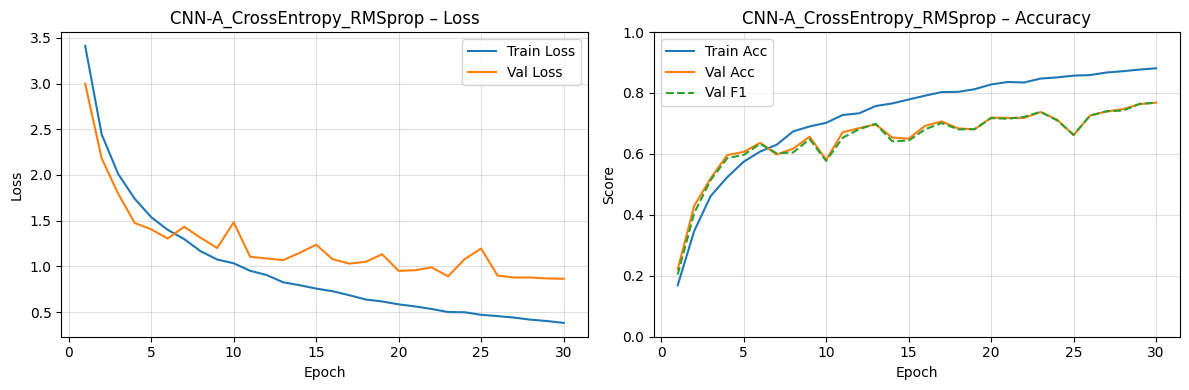

In [15]:
# Melhor experimento por val_acc
best_key = max(results, key=lambda k: results[k]['val_acc'])
best_h   = histories[best_key]
print(f'Melhor experimento: {best_key}  (val_acc={results[best_key]["val_acc"]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(best_h['train_loss']) + 1)

# Loss
axes[0].plot(epochs, best_h['train_loss'], label='Train Loss')
axes[0].plot(epochs, best_h['val_loss'],   label='Val Loss')
axes[0].set_title(f'{best_key} – Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Accuracy
axes[1].plot(epochs, best_h['train_acc'], label='Train Acc')
axes[1].plot(epochs, best_h['val_acc'],   label='Val Acc')
axes[1].plot(epochs, best_h['val_f1'],    label='Val F1', linestyle='--')
axes[1].set_title(f'{best_key} – Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### 6.3 Curvas de todos os experimentos (Val Accuracy)

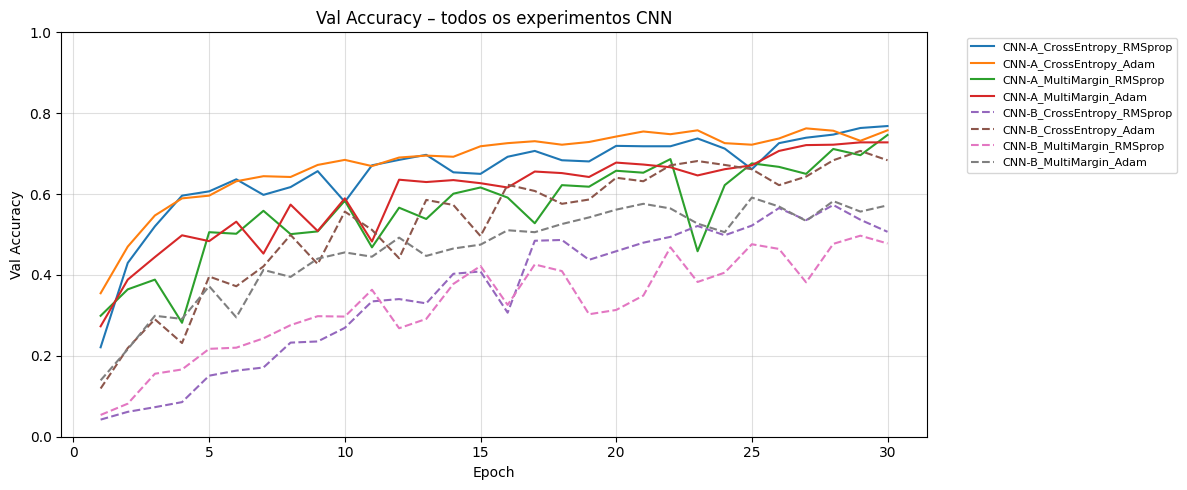

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
for key, h in histories.items():
    style = '-' if 'CNN-A' in key else '--'
    ax.plot(range(1, len(h['val_acc'])+1), h['val_acc'],
            linestyle=style, label=key)
ax.set_title('Val Accuracy – todos os experimentos CNN')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 6.4 Matriz de confusão (melhor experimento)

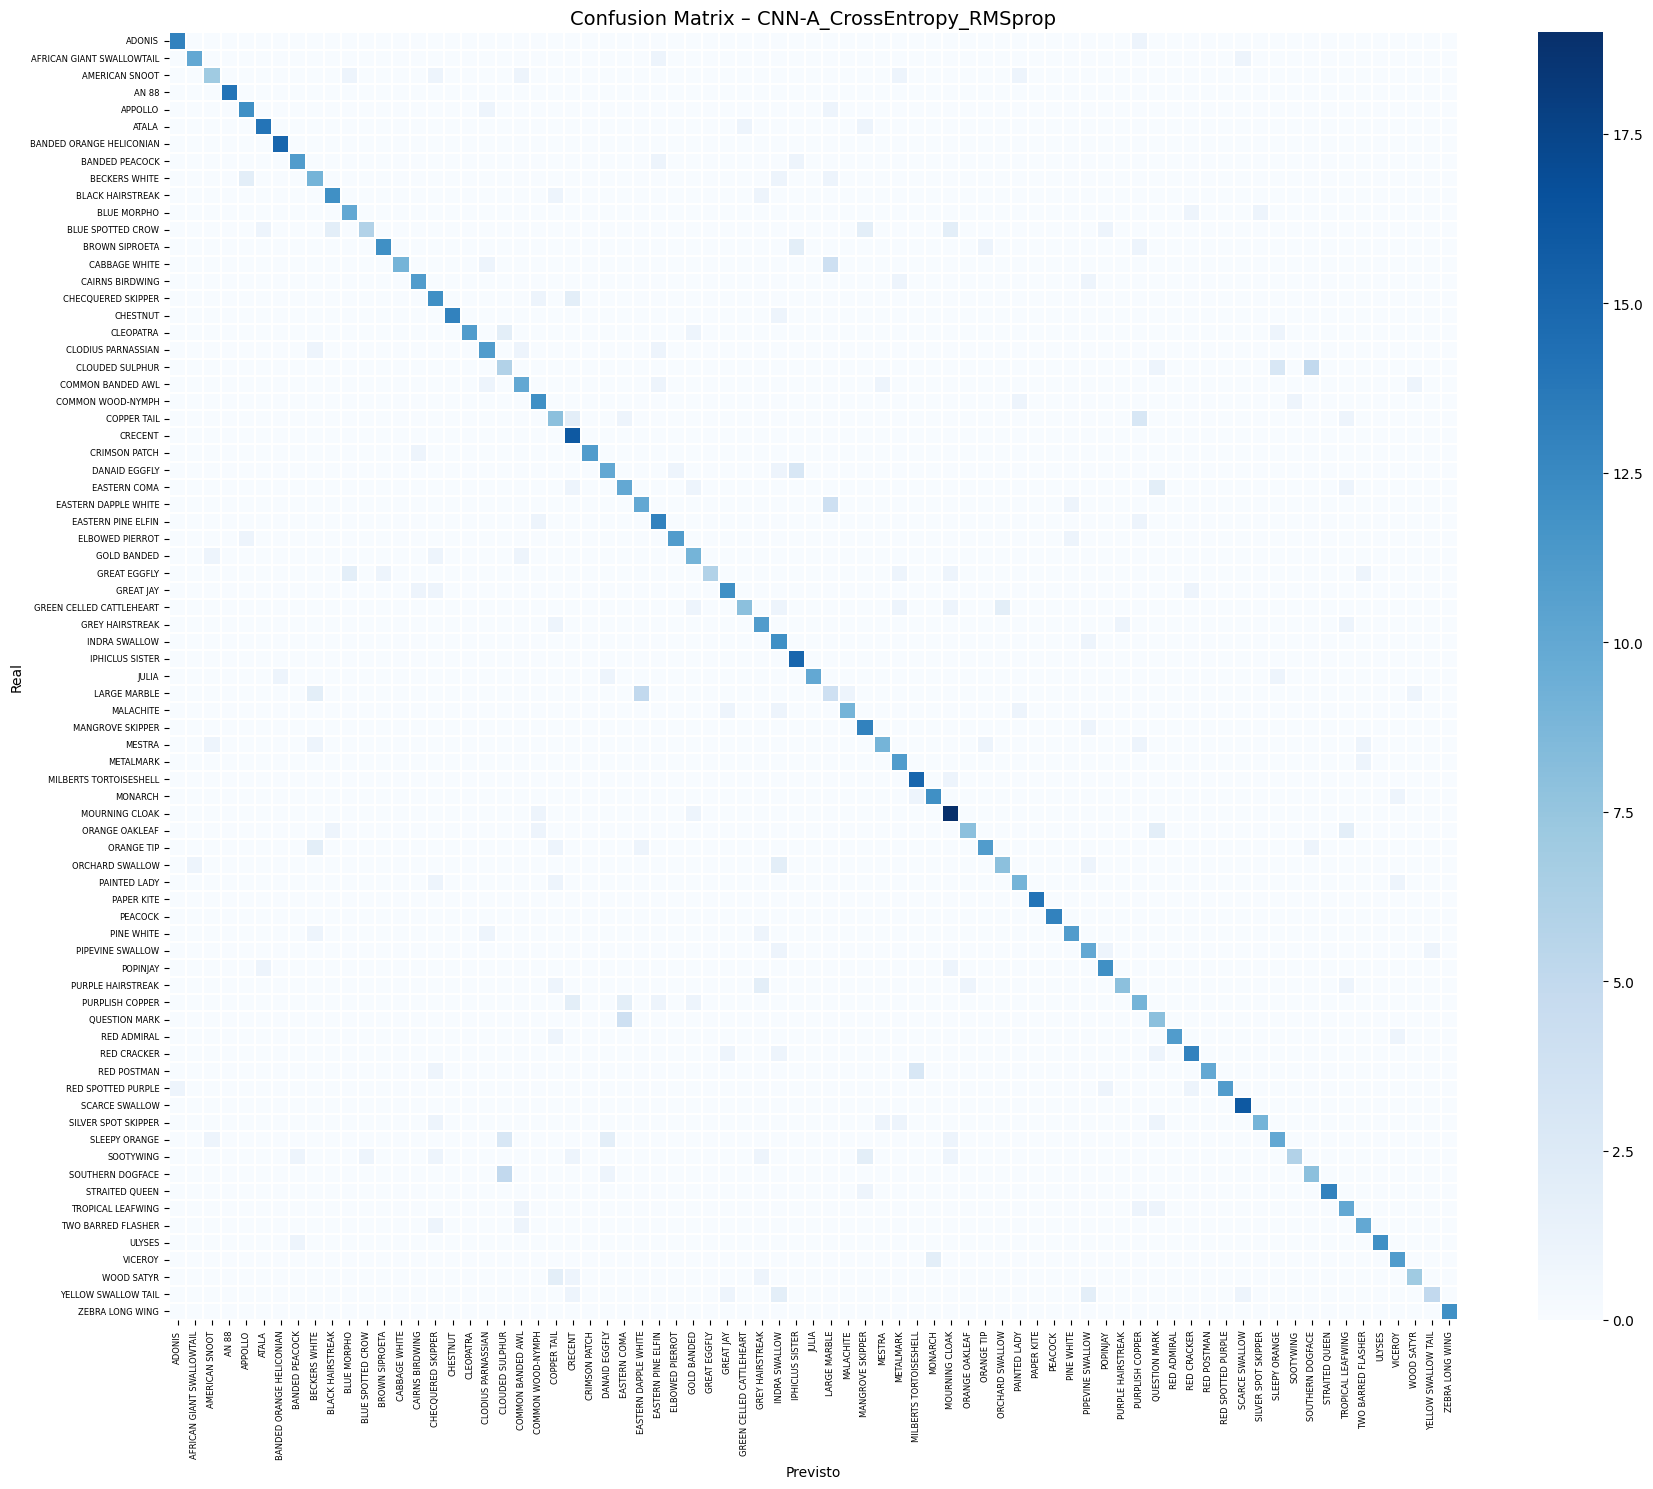

In [17]:
best_preds  = results[best_key]['preds']
best_labels = results[best_key]['labels']

cm = confusion_matrix(best_labels, best_preds)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm, ax=ax,
    xticklabels=classes, yticklabels=classes,
    cmap='Blues', linewidths=0.3,
    annot=False   # 75×75 → demasiado detalhado com texto
)
ax.set_title(f'Confusion Matrix – {best_key}', fontsize=14)
ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.tick_params(axis='y', rotation=0,  labelsize=6)
plt.tight_layout()
plt.show()

### 6.5 Relatório de classificação (melhor experimento)

In [18]:
print(classification_report(
    best_labels, best_preds,
    target_names=classes,
    zero_division=0
))

                           precision    recall  f1-score   support

                   ADONIS       0.93      0.93      0.93        14
AFRICAN GIANT SWALLOWTAIL       0.91      0.83      0.87        12
           AMERICAN SNOOT       0.70      0.58      0.64        12
                    AN 88       1.00      1.00      1.00        14
                  APPOLLO       0.80      0.86      0.83        14
                    ATALA       0.88      0.88      0.88        16
 BANDED ORANGE HELICONIAN       0.94      1.00      0.97        15
           BANDED PEACOCK       0.85      0.85      0.85        13
            BECKERS WHITE       0.56      0.69      0.62        13
         BLACK HAIRSTREAK       0.80      0.86      0.83        14
              BLUE MORPHO       0.77      0.83      0.80        12
        BLUE SPOTTED CROW       0.86      0.43      0.57        14
           BROWN SIPROETA       0.92      0.75      0.83        16
            CABBAGE WHITE       1.00      0.64      0.78     

## 7. Guardar Resultados

Guardamos os resultados em CSV para comparação final no notebook `05_results.ipynb`.

In [19]:
import os, pandas as pd
os.makedirs('../results', exist_ok=True)

rows = []
for key, r in results.items():
    rows.append({
        'Model':        'CNN',
        'Experiment':   key,
        'Val Accuracy': round(r['val_acc'],  4),
        'Macro F1':     round(r['val_f1'],   4),
        'Top-5 Acc':    round(r['val_top5'], 4),
    })

df_cnn = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False)
df_cnn.to_csv('../results/cnn_results.csv', index=False)
print('Resultados guardados em ../results/cnn_results.csv')
df_cnn

Resultados guardados em ../results/cnn_results.csv


,Model,Experiment,Val Accuracy,Macro F1,Top-5 Acc
0,CNN,CNN-A_CrossEntropy_RMSprop,0.7683,0.7681,0.9385
1,CNN,CNN-A_CrossEntropy_Adam,0.7625,0.7612,0.9519
2,CNN,CNN-A_MultiMargin_RMSprop,0.7462,0.7468,0.9413
3,CNN,CNN-A_MultiMargin_Adam,0.7279,0.7245,0.9433
5,CNN,CNN-B_CrossEntropy_Adam,0.7067,0.6996,0.9269
7,CNN,CNN-B_MultiMargin_Adam,0.5913,0.5840,0.8817
4,CNN,CNN-B_CrossEntropy_RMSprop,0.5731,0.5605,0.8692
6,CNN,CNN-B_MultiMargin_RMSprop,0.4971,0.4722,0.8510


## 8. Análise e Conclusões

### CNN vs MLP para classificação de imagens
As CNNs exploram explicitamente a **estrutura espacial** das imagens através de filtros convolucionais partilhados:
- **Partilha de pesos**: o mesmo filtro é aplicado em toda a imagem → muito menos parâmetros que o MLP para a mesma capacidade representativa.
- **Invariância à translação**: MaxPooling e convoluções tornam o modelo robusto a pequenas deslocações do motivo.
- **Hierarquia de features**: camadas iniciais detetam bordas/texturas; camadas profundas combinam-nas em padrões complexos (ex: padrões de asas).

### Comparação de arquitecturas
- **CNN-A** (3 blocos, mais parâmetros FC): mais susceptível a overfitting nas camadas lineares.
- **CNN-B** (6 blocos + AdaptiveAvgPool): head FC mais pequeno → melhor regularização, geralmente superior em datasets pequenos.

### Comparação de losses
- **CrossEntropyLoss**: geralmente melhor resultado; penalização contínua por probabilidade.
- **MultiMarginLoss**: maximiza margens; pode convergir mais lentamente em CNN.

### Limitações
- Sem pre-training (treino de raiz): limita a capacidade de generalização comparativamente a modelos pré-treinados (ver `04_resnet.ipynb`).
- Dataset pequeno (~5200 imagens / 75 classes): overfitting ainda presente, mesmo com augmentation.